In [1]:
# Bagpipes tutorial
#Designed by William Baker but borrowing heavily from the Bagpipes Demos https://github.com/ACCarnall/bagpipes/tree/master

import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astropy.units as u
from astropy.table import Table 
from matplotlib import gridspec
from astropy.cosmology import Planck18 as cosmo

Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


In [2]:
#We need a list directing bagpipes to the filter curves used for the photometric fits 
#You should have the filter curves saved in a directory called filters
filter_list=np.loadtxt('filter_list.txt', dtype='str')


In [3]:
#load in the photometry from the fits file
def load_photometry(ID):
    # Load the photometry data from a file
    # wavelength is in AA, flux is in nJy, flux_err is in nJy
    data = Table.read(f'photometry/{ID}_photometry.fits', format='fits')

    #bagpipes default is to fit in muJy so convert from nJy to muJy
    flux = 1e-3 * data['mags_obs'][:10] #only taking up to 10th flux as not fitting hst photometry here for convenience
    flux_err = 1e-3 * data['mags_unc_obs'][:10]
    wavelength= data['wavelength'][:10]

    flux_cgs= (flux*u.uJy).to(u.erg / u.s / u.cm**2 / u.AA,
                equivalencies=u.spectral_density(wavelength * u.AA)).value
    flux_cgs_err = (flux_err*u.uJy).to(u.erg / u.s / u.cm**2 / u.AA,
                equivalencies=u.spectral_density(wavelength * u.AA)).value
    
    #add in error floor
    flux_cgs_err=np.clip(flux_cgs_err, 0.05*flux_cgs, np.inf)

    photometry = np.c_[flux_cgs, flux_cgs_err]

    return photometry
           

In [4]:

file_path=f'gds-barrufet-s67-v3_prism-clear_2198_{8290}.spec.fits'
with fits.open(file_path) as hdul:
    data = hdul["SPEC1D"].data
    #remove nans from spectrum
    mask = np.isnan(data['flux'])
    data['flux'][mask] = 0.0
    data['err'][mask] = 1e30

    wavelength = 1e4*data['wave']
    flux = data['flux']
    flux_err = data['err']


    spectrum = np.c_[wavelength, flux, flux_err]
    mask = (spectrum[:,0] < 51000.) & (spectrum[:,0] > 9000.)
    print(f"Spectrum: {spectrum}")
    #return wavelength, spectrum


idx=np.where((((wavelength)/(1+4.36))>5470) & (((wavelength)/(1+4.36))<5520))
flux_in_v=flux[idx]

from astropy import units as u

flux_ujy=flux_in_v*u.uJy

mag=flux_ujy.to(u.ABmag)
print(f"AB mag is {mag}")





Spectrum: [[5.80000000e+03 0.00000000e+00 1.00000000e+30]
 [5.83685109e+03 0.00000000e+00 1.00000000e+30]
 [5.87437877e+03 0.00000000e+00 1.00000000e+30]
 ...
 [5.32249980e+04 0.00000000e+00 1.00000000e+30]
 [5.32956424e+04 0.00000000e+00 1.00000000e+30]
 [5.33661817e+04 0.00000000e+00 1.00000000e+30]]
AB mag is [23.87459108 23.89025356] mag(AB)


In [5]:
def load_nirspec_spectrum(ID, plotting=False):
    #Load the spectrum from the FITS file
    if ID=='8290':
        file_path='gds-barrufet-s67-v3_prism-clear_2198_8290.spec.fits'
    elif ID=='6620':
        file_path='gds-barrufet-s67-v3_prism-clear_2198_6620.spec.fits'
    file_path=f'gds-barrufet-s67-v3_prism-clear_2198_{ID}.spec.fits'

    with fits.open(file_path) as hdul:
        data = hdul["SPEC1D"].data
        #remove nans from spectrum
        mask = np.isnan(data['flux'])
        data['flux'][mask] = 0.0
        data['err'][mask] = 1e30

        wavelength = 1e4*data['wave']
        flux = data['flux']
        flux_err = data['err']

        flux_cgs= (flux*u.uJy).to(u.erg / u.s / u.cm**2 / u.AA,
                equivalencies=u.spectral_density(wavelength * u.AA)).value
        flux_cgs_err = (flux_err*u.uJy).to(u.erg / u.s / u.cm**2 / u.AA,
                equivalencies=u.spectral_density(wavelength * u.AA)).value

    
    # flux is in muJys already

    if plotting:
        return wavelength, flux, flux_err
    else:
        spectrum = np.c_[wavelength, flux_cgs, flux_cgs_err]
        mask = (spectrum[:,0] < 51000.) & (spectrum[:,0] > 7000.)
        #print(f"Spectrum: {spectrum}")
        return spectrum[mask]

def load_both(ID):
    spectrum = load_nirspec_spectrum(ID)
    phot = load_photometry(ID)

    return spectrum, phot

load_nirspec_spectrum(6620)

array([[ 7.03996930e+03,  8.70549675e-21,  5.81629170e-21],
       [ 7.10285609e+03,  1.63946038e-20,  7.57060155e-21],
       [ 7.16721913e+03, -2.07985574e-21,  5.40968973e-21],
       ...,
       [ 5.08318723e+04,  1.26350013e-20,  1.06839544e-21],
       [ 5.09062373e+04,  1.39079478e-20,  1.41068182e-21],
       [ 5.09804819e+04,  1.37969601e-20,  1.35875763e-21]],
      shape=(376, 3))

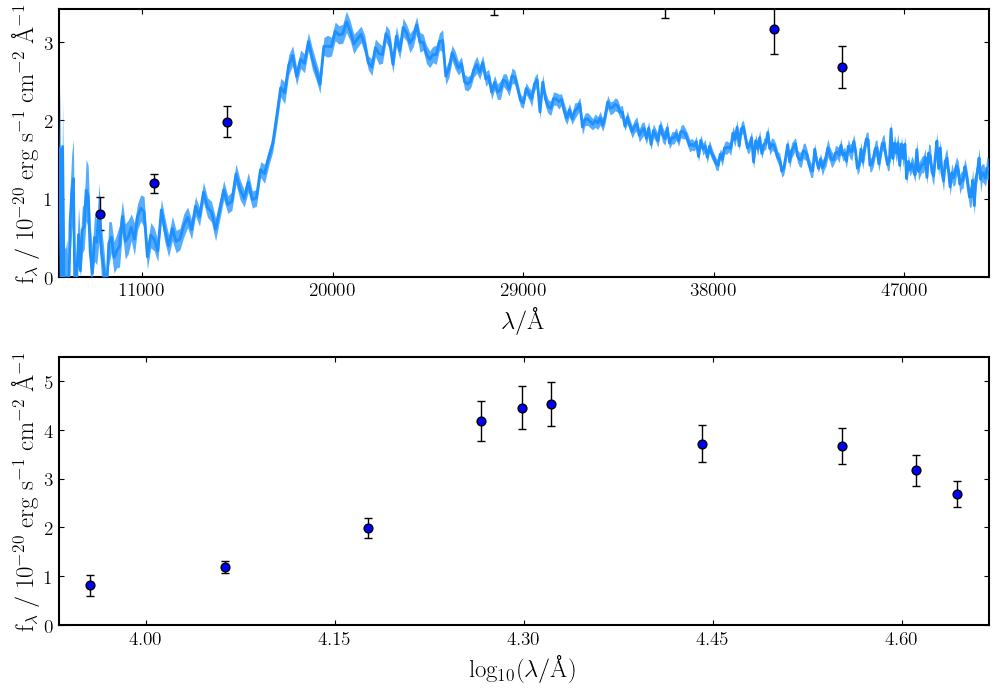

In [6]:
#ID=8290
ID=6620
# galaxy = pipes.galaxy(ID, load_nirspec_spectrum,  photometry_exists=False, #filt_list=filter_list,
#                           spec_units='mujy')#, phot_units='mujy')
galaxy = pipes.galaxy(ID, load_both, photometry_exists=True, spectrum_exists=True, filt_list=filter_list, phot_units='muJy') #, spec_units='muJy', phot_units='muJy')
fig=galaxy.plot()



In [7]:
# Define the model components
nebular = {"logU": (-4.5, -1.0)}
fit_instructions = {}
sfh='dblplaw'
#sfh='delayed'
fix_redshift=False
z_prior=3.3

if fix_redshift:
    fit_instructions["redshift"] = z_fix
else:
    fit_instructions["redshift"] = (0.0, 10.0)
    # fit_instructions["redshift_prior"] = "Gaussian"
    # fit_instructions["redshift_prior_mu"] = z_prior
    # fit_instructions["redshift_prior_sigma"] = 1.0

if sfh == 'delayed':
    delayed = {"tau": (0.1, 10), "age": (0.0, 15.0), "massformed": (5.0, 13.0), "metallicity": (0.0, 2.5)}
    fit_instructions["delayed"] = delayed
elif sfh == "dblplaw":
    dblplaw = {}                        
    dblplaw["tau"] = (0., 15.)                # Vary the time of peak star-formation between
                                            # the Big Bang at 0 Gyr and 15 Gyr later. In 
                                            # practice the code automatically stops this
                                            # exceeding the age of the universe at the 
                                            # observed redshift.
                
    dblplaw["alpha"] = (0.01, 1000.)          # Vary the falling power law slope from 0.01 to 1000.
    dblplaw["beta"] = (0.01, 1000.)           # Vary the rising power law slope from 0.01 to 1000.
    dblplaw["alpha_prior"] = "log_10"         # Impose a prior which is uniform in log_10 of the 
    dblplaw["beta_prior"] = "log_10"          # parameter between the limits which have been set 
                                            # above as in Carnall et al. (2017).
    dblplaw["massformed"] = (6., 15.)
    dblplaw["metallicity"] = (0., 2.5)
    fit_instructions["dblplaw"] = dblplaw

#we also need to account for the presence of dust  there multiple different prescriptions one can use

dust = {}                                 # Dust component
dust["type"] = "Calzetti"                 # Define the shape of the attenuation curve
dust["Av"] = (0., 4.)                     # Vary Av between 0 and 2 magnitudes

fit_instructions["dust"] = dust
fit_instructions["nebular"] = nebular

In [8]:
#Now we come to specifics of fitting spectra
#Here we fit for velocity dispersion - i.e. shifts in the spectrum due to rotation, outflows etc.
#We are not really worried about this as we are fitting low resolution prism data, but if we fit higher resolution data this becomes very important

fit_instructions["veldisp"] = (1., 1000.)   #km/s
fit_instructions["veldisp_prior"] = "log_10"

    

In [9]:
#Now we need to account for the variable spectral resolution of the NIRSpec Prism - we use this curve provided by STsci
hdul = fits.open("jwst_nirspec_prism_disp.fits")
fit_instructions["R_curve"] = np.c_[10000*hdul[1].data["WAVELENGTH"], hdul[1].data["R"]]

In [10]:
# mlpoly = {}
# mlpoly["type"] = "polynomial_max_like"
# mlpoly["order"] = 2

# fit_instructions["mlpoly"]=mlpoly

In [11]:
#Calibration polynomial
calib = {}
calib["type"] = "polynomial_bayesian"

calib["0"] = (0.5, 1.5) # Zero order is centred on 1, at which point there is no change to the spectrum.
calib["0_prior"] = "Gaussian"
calib["0_prior_mu"] = 1.0
calib["0_prior_sigma"] = 0.25

calib["1"] = (-0.5, 0.5) # Subsequent orders are centred on zero.
calib["1_prior"] = "Gaussian"
calib["1_prior_mu"] = 0.
calib["1_prior_sigma"] = 0.25

calib["2"] = (-0.5, 0.5)
calib["2_prior"] = "Gaussian"
calib["2_prior_mu"] = 0.
calib["2_prior_sigma"] = 0.25

fit_instructions["calib"] = calib


In [12]:
#Need to account for noise in the spectral pixels
noise = {}
noise["type"] = "white_scaled"
noise["scaling"] = (1., 10.)
noise["scaling_prior"] = "log_10"
fit_instructions["noise"] = noise

In [13]:
fit = pipes.fit(galaxy, fit_instructions, run=f"fit_phot_and_spec_{ID}_22jul_v13mlpoly")
fit.fit(verbose=True, n_live=800, sampler='nautilus', pool=7)


Results loaded from pipes/posterior/fit_phot_and_spec_6620_22jul_v13mlpoly/6620.h5

Fitting not performed as results have already been loaded from pipes/posterior/fit_phot_and_spec_6620_22jul_v13mlpoly/6620.h5. To start over delete this file or change run.



/opt/anaconda3/envs/pipes/lib/python3.13/site-packages/bagpipes/models/star_formation_history.py:278: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


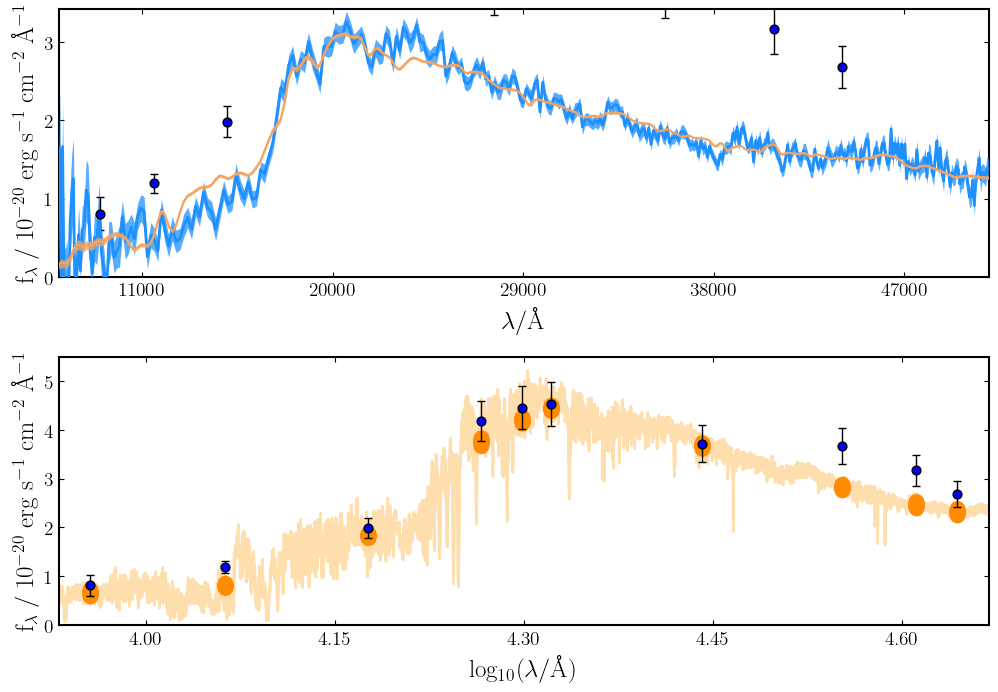

(<Figure size 1200x800 with 2 Axes>,
 [<Axes: xlabel='$\\lambda / \\mathrm{\\AA}$', ylabel='$\\mathrm{f_{\\lambda}}\\ \\mathrm{/\\ 10^{-20}\\ erg\\ s^{-1}\\ cm^{-2}\\ \\AA^{-1}}$'>,
  <Axes: xlabel='$\\mathrm{log_{10}}\\big(\\lambda / \\mathrm{\\AA}\\big)$', ylabel='$\\mathrm{f_{\\lambda}}\\ \\mathrm{/\\ 10^{-20}\\ erg\\ s^{-1}\\ cm^{-2}\\ \\AA^{-1}}$'>])

In [14]:
# Plot the results
fit.plot_spectrum_posterior(save=False, show=True)

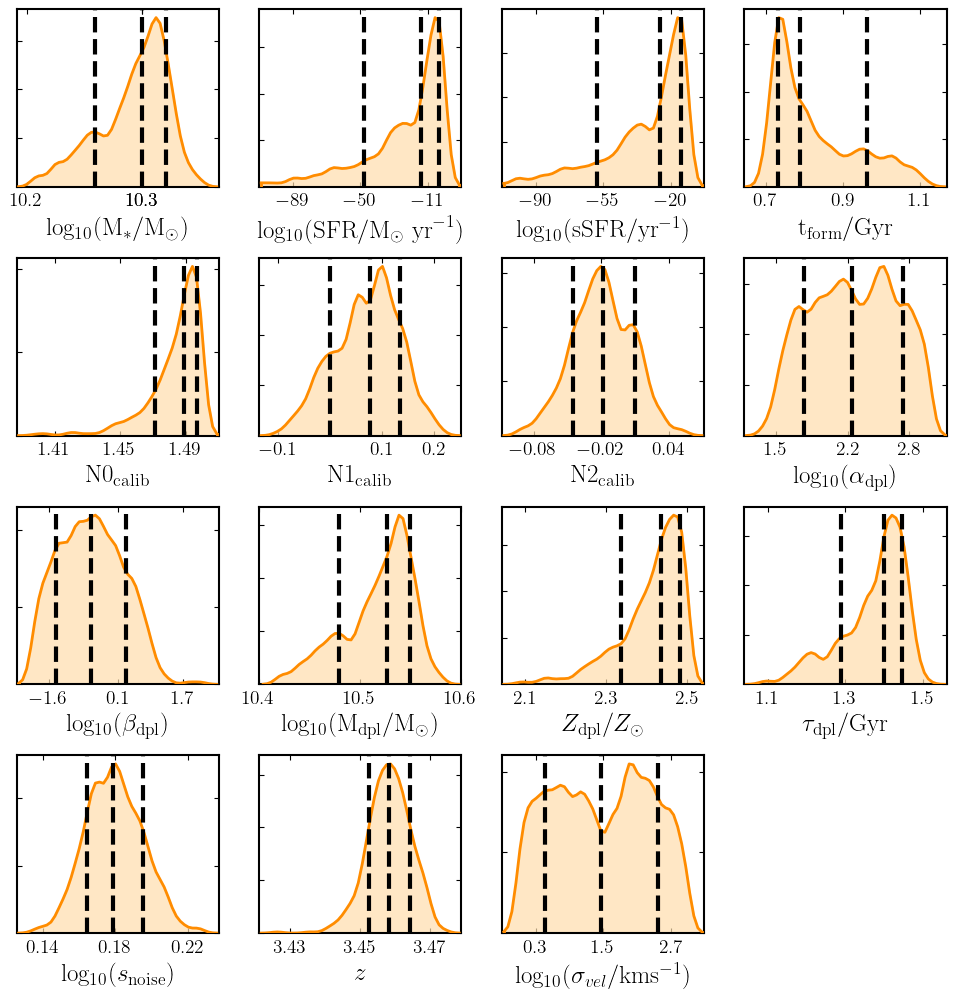

(<Figure size 1200x1200 with 15 Axes>,
 [<Axes: xlabel='$\\mathrm{log_{10}(M_*/M_{\\odot})}$'>,
  <Axes: xlabel='$\\mathrm{log_{10}}(\\mathrm{SFR}/\\mathrm{M_\\odot\\ yr}^{-1})$'>,
  <Axes: xlabel='$\\mathrm{log_{10}(sSFR/\\mathrm{yr}^{-1})}$'>,
  <Axes: xlabel='$\\mathrm{t_{form}}/\\mathrm{Gyr}$'>,
  <Axes: xlabel='$\\mathrm{N}0_\\mathrm{calib}$'>,
  <Axes: xlabel='$\\mathrm{N}1_\\mathrm{calib}$'>,
  <Axes: xlabel='$\\mathrm{N}2_\\mathrm{calib}$'>,
  <Axes: xlabel='$\\mathrm{log_{10}}(\\alpha_\\mathrm{dpl})$'>,
  <Axes: xlabel='$\\mathrm{log_{10}}(\\beta_\\mathrm{dpl})$'>,
  <Axes: xlabel='$\\mathrm{log_{10}(M_\\mathrm{dpl}/M_{\\odot})}$'>,
  <Axes: xlabel='$Z_\\mathrm{dpl}/Z_{\\odot}$'>,
  <Axes: xlabel='$\\tau_\\mathrm{dpl}/\\mathrm{Gyr}$'>,
  <Axes: xlabel='$\\mathrm{log_{10}}(s_\\mathrm{noise})$'>,
  <Axes: xlabel='$z$'>,
  <Axes: xlabel='$\\mathrm{log_{10}}(\\sigma_{vel}/\\mathrm{km s^{-1}})$'>])

In [15]:
fit.plot_1d_posterior(save=False, show=True) 

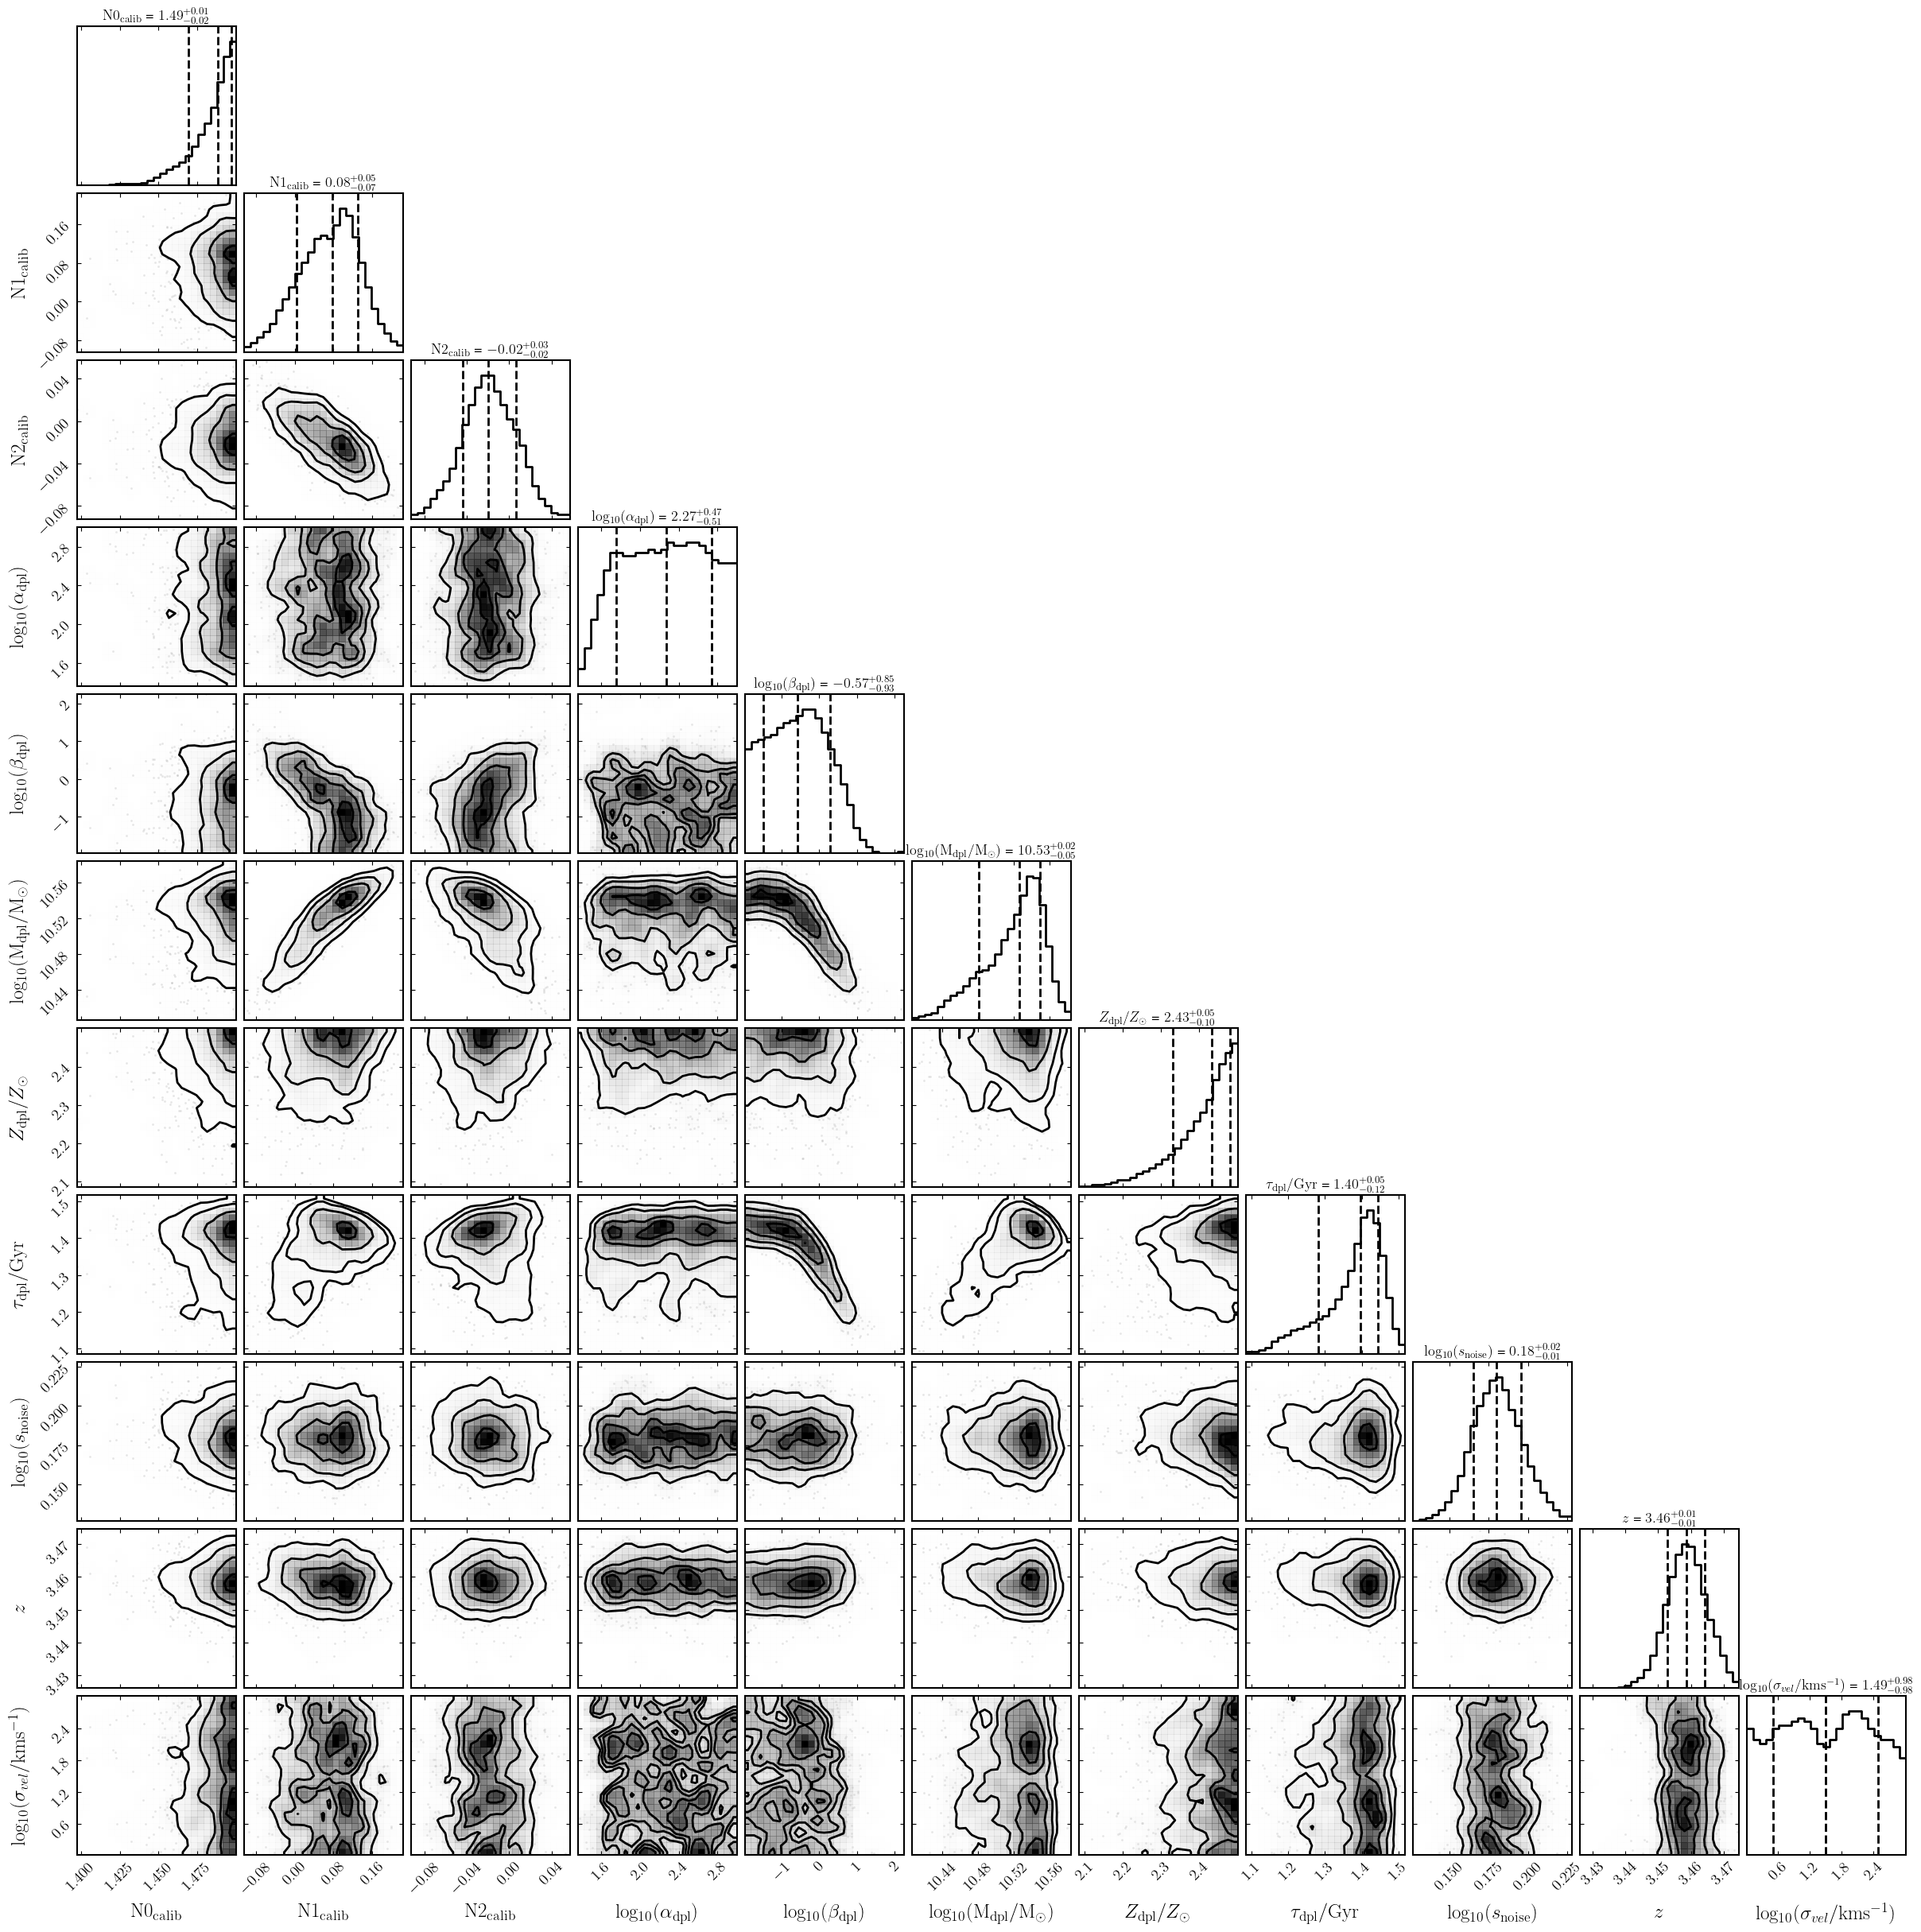

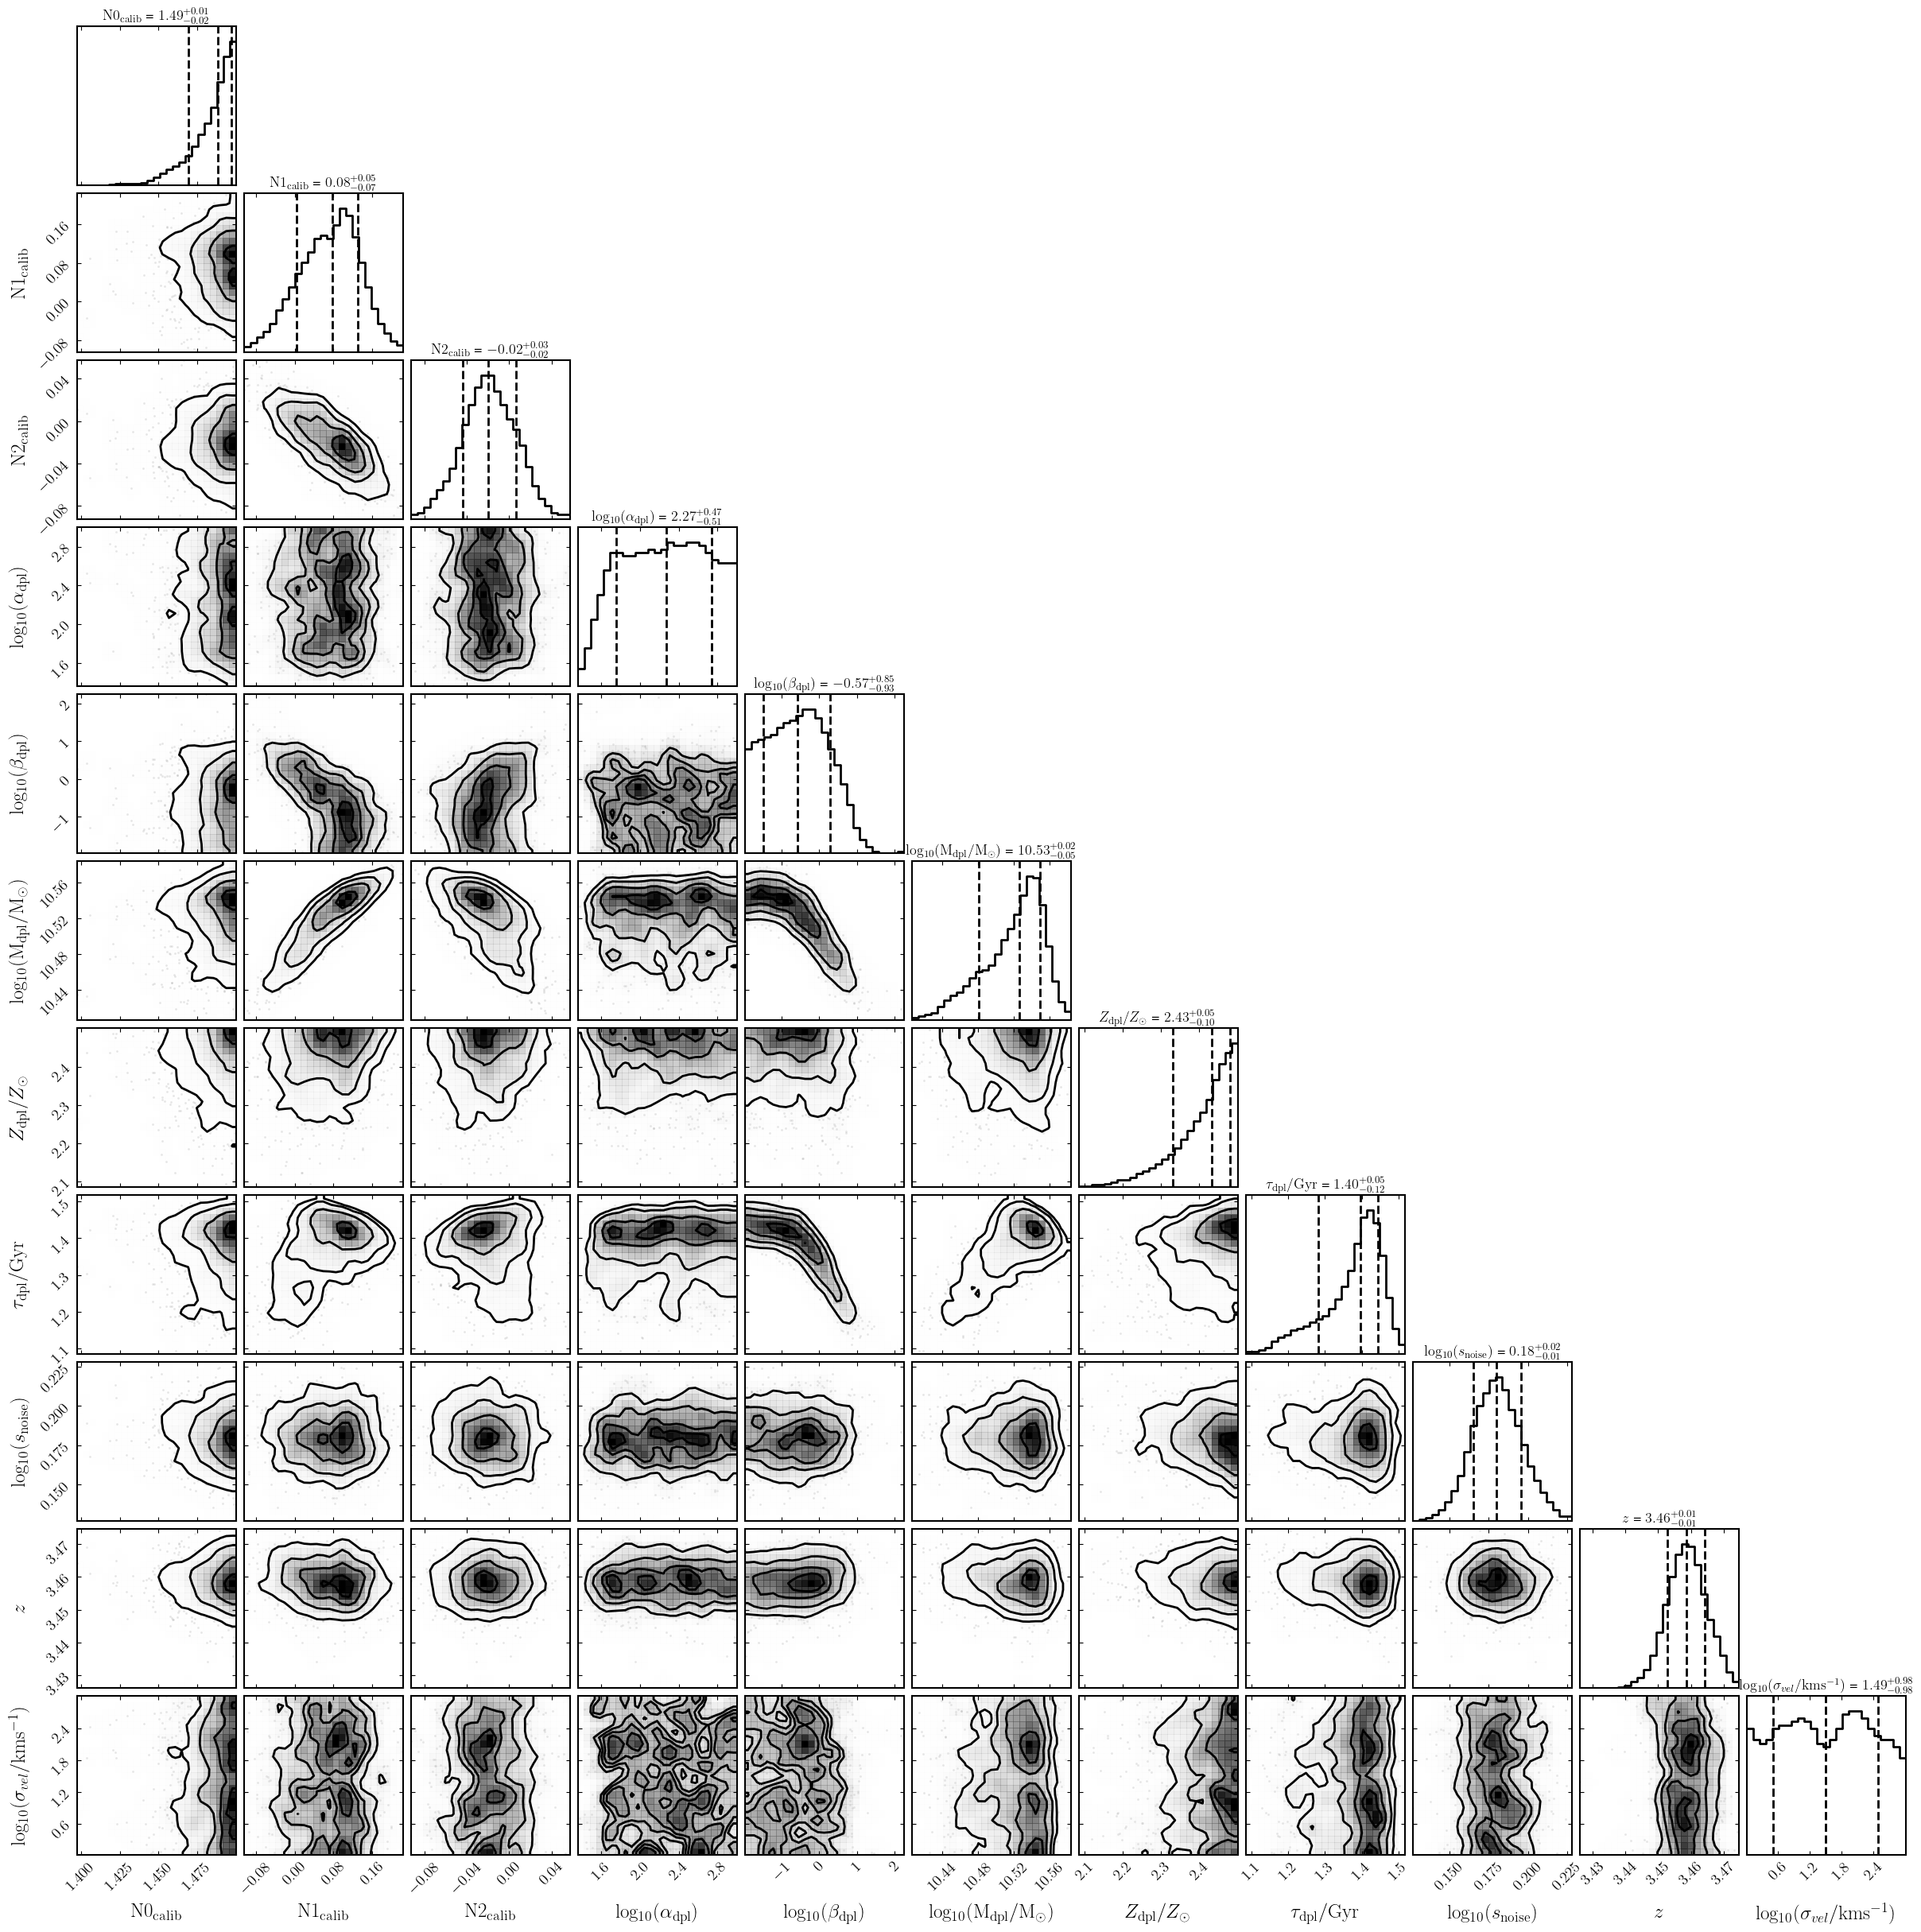

In [16]:
fit.plot_corner(save=False, show=True)

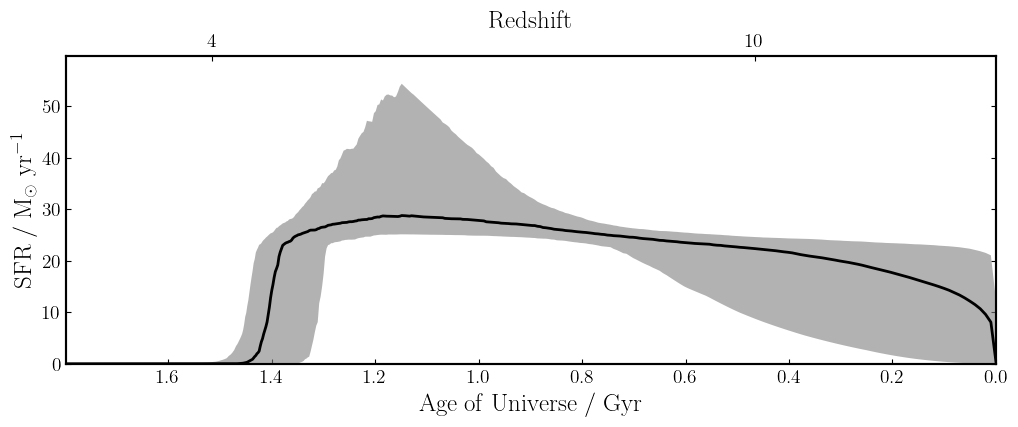

(<Figure size 1200x400 with 2 Axes>,
 <Axes: xlabel='$\\mathrm{Age\\ of\\ Universe\\ /\\ Gyr}$', ylabel='$\\mathrm{SFR\\ /\\ M_\\odot\\ \\mathrm{yr}^{-1}}$'>)

In [17]:
fit.plot_sfh_posterior(save=False, show=True) 

In [18]:
fit.posterior.sfh.tform
fit.posterior.sfh.tquench


np.float64(1.4292472299986951)

In [19]:
dir(fit)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_print_results',
 'fit',
 'fit_instructions',
 'fitted_model',
 'fname',
 'galaxy',
 'n_posterior',
 'plot_1d_posterior',
 'plot_calibration',
 'plot_corner',
 'plot_sfh_posterior',
 'plot_spectrum_posterior',
 'posterior',
 'results',
 'run']

In [20]:
fit.posterior.samples.keys()


dict_keys(['calib:0', 'calib:1', 'calib:2', 'dblplaw:alpha', 'dblplaw:beta', 'dblplaw:massformed', 'dblplaw:metallicity', 'dblplaw:tau', 'noise:scaling', 'redshift', 'veldisp', 'stellar_mass', 'formed_mass', 'sfr', 'ssfr', 'nsfr', 'mass_weighted_age', 'tform', 'tquench', 'mass_weighted_zmet', 'sfh', 'photometry', 'spectrum', 'spectrum_full', 'uvj', 'chisq_phot', 'calib'])

In [21]:
fit.posterior.samples['uvj']

array([[5.08796229, 3.4816545 , 2.61166251],
       [5.05740693, 3.45647413, 2.58429363],
       [5.07657302, 3.47616287, 2.6085408 ],
       ...,
       [5.08871235, 3.47857015, 2.60606021],
       [5.05781992, 3.47341575, 2.63823023],
       [5.05821897, 3.45087091, 2.57593926]], shape=(500, 3))

In [22]:
fit.results.keys()
fit.results['lnz']

array(73.63156968)

In [23]:
fit.results['median']

array([ 1.48836552e+00,  7.69917342e-02, -1.97621996e-02,  1.85641908e+02,
        2.70754618e-01,  1.05262752e+01,  2.43174431e+00,  1.39756748e+00,
        1.51295014e+00,  3.45854942e+00,  3.09956614e+01])

In [24]:

ssfr=np.median(fit.posterior.samples['ssfr'])
print(ssfr)

-25.430153801004547


In [25]:
10**ssfr

np.float64(3.7140367694346903e-26)

In [26]:
from astropy.cosmology import Planck18
t_age=(Planck18.age(np.median(fit.posterior.samples['redshift']))).to("yr").value


In [27]:
10**ssfr<0.2/t_age

np.True_

In [28]:
print(10**ssfr)

3.7140367694346903e-26


In [29]:
0.2/t_age

np.float64(1.096279469912991e-10)

In [30]:
# def uvj_criteria_extended(ax):
# 			#uvj_q=(col(U,V)>1.3) & (col(V,J)<1.6) & (col(U,V)>0.88*col(V,J)+0.49)

# 			ax.hlines(1.3, xmin=-2.5, xmax=0.92, ls='dashed', color='black', lw=3)
# 			ax.vlines(1.6, ymin=1.898, ymax=3, ls='dashed', color='black', lw=3)
# 			ax.plot(np.linspace(0.92,1.6, 100), 0.88*np.linspace(0.92,1.6,100)+0.49, color='black', lw=4, ls='dashed', zorder=4)
# 			ax.plot(np.linspace(-0.5,0.92, 100), 0.88*np.linspace(-0.5,0.92,100)+0.49, color='gray', lw=4, ls='dashed', zorder=3)

# 			ax.plot(np.linspace(0.,1.6, 100), 1.30*np.linspace(0, 1.6, 100)-0.2, color='C3', lw=4, ls='dotted', zorder=5)

In [32]:
#If stuck - some old code for volumes (will need editing!)
# n_gal[i]=len(self.tab_q[(self.tab_q['redshift_50']>z_bins[i]) & (self.tab_q['redshift_50']<z_bins[i+1])])
# Omega     = (area*u.arcmin**2).to(u.steradian).value
# d1        = cosmo.comoving_distance(z_bins[i])
# d2        = cosmo.comoving_distance(z_bins[i+1])
# V[i]        = (Omega/3 * (d2**3 - d1**3)).value
# V[i] 	  = (4/3*np.pi*(area*u.arcmin**2)/(41253*u.deg**2).to("arcmin^2") * (d2.value**3 - d1.value**3)).value

In [ ]:
# def schechter(m, phi_star, m_star, alpha):
# 	"""Schechter function in log10(M) space."""
# 	m = np.asarray(m)
# 	x = 10**(m - m_star)
# 	return phi_star * (x**alpha) * np.exp(-x) * np.log(10)

### 4.1 — Spectral fitting of the NIRSpec prism spectrum

Bagpipes: Latex turned off in rcParams, plots may look strange.
Spectrum shape: (376, 3)
Wavelength range [Å]: 7039.969298328147 – 50980.481902359454


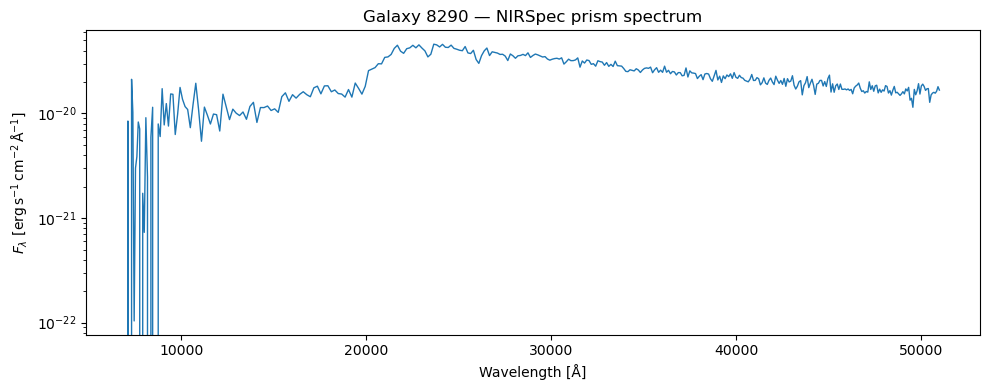


Bagpipes: fitting object 8290

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Bagpipes: Latex turned off in rcParams, plots may look strange.0     | N/A      
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Finished  | 43     | 2        | 4        | 37300    | N/A    | 5726  | -592.60  

Completed in 179.3 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
calib:0                        0.748      0.841      0.940
calib:1                        0.375      0.424      0.473
calib:2                        0.224      0.252      0.286
delayed:age                    1.442      1.806      2.207
de

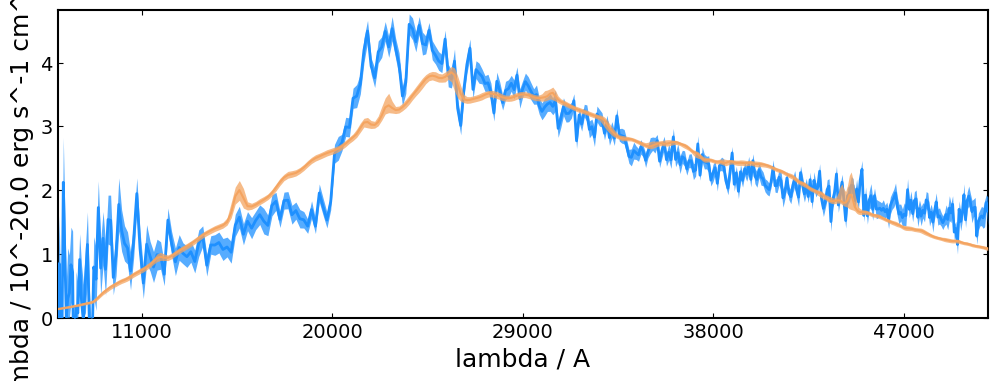

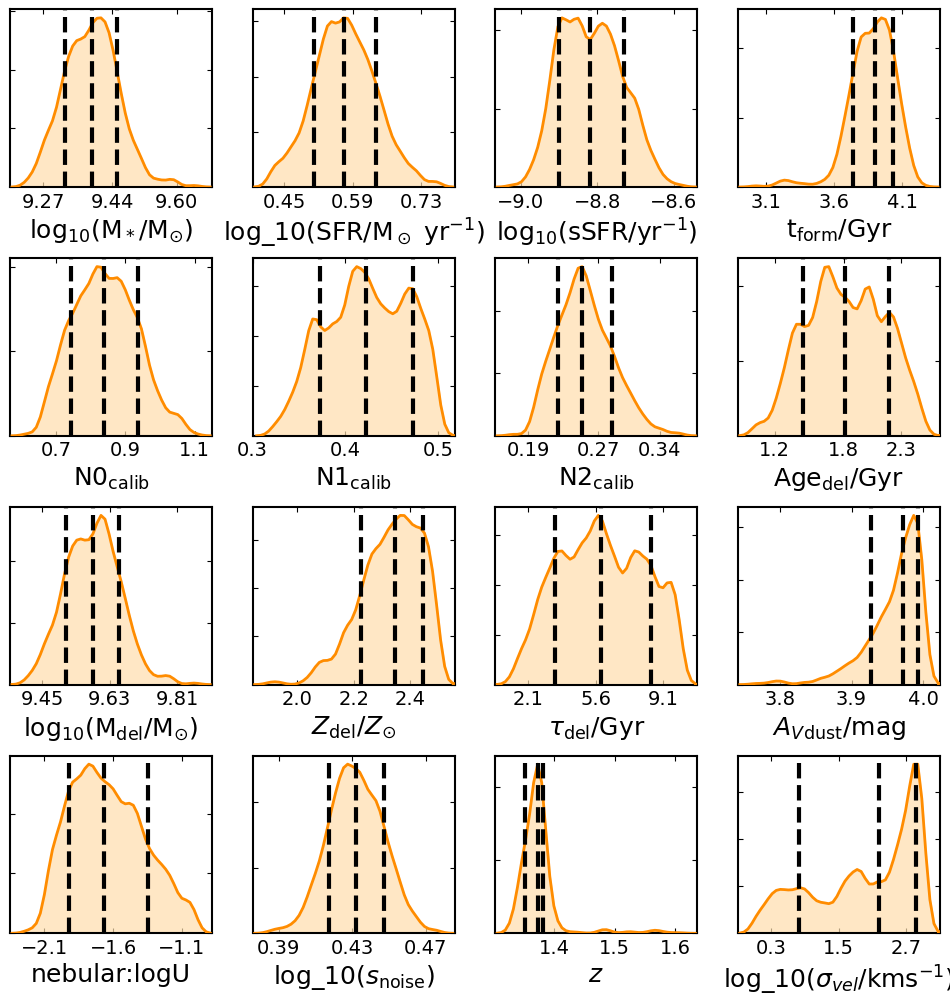

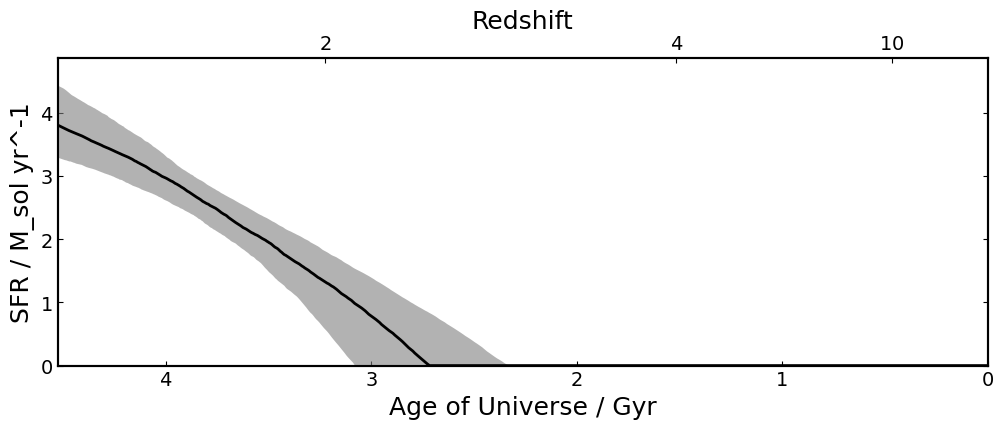

(<Figure size 1200x400 with 2 Axes>,
 <Axes: xlabel='Age of Universe / Gyr', ylabel='SFR / M_sol yr^-1'>)

In [1]:
# ============================================================
# 4.1  Spectrum-only fitting of the NIRSpec prism spectrum
#      Galaxy 8290 | delayed SFH | Calzetti dust | z free
# ============================================================

import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astropy.units as u

# ------------------------------------------------------------
# Load NIRSpec prism spectrum
# ------------------------------------------------------------
def load_nirspec_spectrum(ID, plotting=False):

    file_path = f"gds-barrufet-s67-v3_prism-clear_2198_{ID}.spec.fits"

    with fits.open(file_path) as hdul:
        data = hdul["SPEC1D"].data

        # replace NaNs
        mask = np.isnan(data["flux"])
        data["flux"][mask] = 0.0
        data["err"][mask] = 1e30

        wavelength = 1e4 * data["wave"]   # micron -> Å
        flux = data["flux"]               # µJy
        flux_err = data["err"]            # µJy

        # convert to cgs F_lambda for Bagpipes spectral fitting
        flux_cgs = (flux * u.uJy).to(
            u.erg / u.s / u.cm**2 / u.AA,
            equivalencies=u.spectral_density(wavelength * u.AA)
        ).value

        flux_cgs_err = (flux_err * u.uJy).to(
            u.erg / u.s / u.cm**2 / u.AA,
            equivalencies=u.spectral_density(wavelength * u.AA)
        ).value

    if plotting:
        return wavelength, flux, flux_err

    spectrum = np.c_[wavelength, flux_cgs, flux_cgs_err]

    # keep useful prism range
    mask = (spectrum[:, 0] > 7000.) & (spectrum[:, 0] < 51000.)
    return spectrum[mask]

# ------------------------------------------------------------
# Quick look at observed spectrum
# ------------------------------------------------------------
ID = "8290"
spec = load_nirspec_spectrum(ID)

print("Spectrum shape:", spec.shape)
print("Wavelength range [Å]:", spec[:,0].min(), "–", spec[:,0].max())

plt.figure(figsize=(10,4))
plt.plot(spec[:,0], spec[:,1], lw=1)
plt.yscale("log")
plt.xlabel("Wavelength [Å]")
plt.ylabel(r"$F_\lambda\ [\mathrm{erg\,s^{-1}\,cm^{-2}\,\AA^{-1}}]$")
plt.title(f"Galaxy {ID} — NIRSpec prism spectrum")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Build spectrum-only galaxy object
# ------------------------------------------------------------
galaxy = pipes.galaxy(
    ID,
    load_nirspec_spectrum,
    spectrum_exists=True,
    photometry_exists=False
)

# ------------------------------------------------------------
# Fit instructions: delayed SFH + Calzetti dust + free z
# ------------------------------------------------------------
fit_instructions = {}

# free redshift with uniform prior
fit_instructions["redshift"] = (0.0, 10.0)

# delayed SFH
fit_instructions["delayed"] = {
    "tau": (0.1, 10.0),
    "age": (0.01, 2.5),
    "massformed": (6.0, 13.5),
    "metallicity": (0.0, 2.5),
}

# dust
fit_instructions["dust"] = {
    "type": "Calzetti",
    "Av": (0.0, 4.0)
}

# nebular
fit_instructions["nebular"] = {
    "logU": (-4.5, -1.0)
}

# velocity dispersion
fit_instructions["veldisp"] = (1.0, 1000.0)
fit_instructions["veldisp_prior"] = "log_10"

# prism resolution curve
with fits.open("jwst_nirspec_prism_disp.fits") as hdul:
    fit_instructions["R_curve"] = np.c_[
        10000 * hdul[1].data["WAVELENGTH"],
        hdul[1].data["R"]
    ]

# calibration polynomial
calib = {}
calib["type"] = "polynomial_bayesian"
calib["0"] = (0.5, 1.5)
calib["0_prior"] = "Gaussian"
calib["0_prior_mu"] = 1.0
calib["0_prior_sigma"] = 0.25

calib["1"] = (-0.5, 0.5)
calib["1_prior"] = "Gaussian"
calib["1_prior_mu"] = 0.0
calib["1_prior_sigma"] = 0.25

calib["2"] = (-0.5, 0.5)
calib["2_prior"] = "Gaussian"
calib["2_prior_mu"] = 0.0
calib["2_prior_sigma"] = 0.25

fit_instructions["calib"] = calib

# noise scaling
noise = {}
noise["type"] = "white_scaled"
noise["scaling"] = (1.0, 10.0)
noise["scaling_prior"] = "log_10"
fit_instructions["noise"] = noise

# ------------------------------------------------------------
# Run fit
# ------------------------------------------------------------
run_name = f"spec_only_{ID}_delayed_zfree"

fit_spec = pipes.fit(galaxy, fit_instructions, run=run_name)
fit_spec.fit(verbose=True, sampler="nautilus", n_live=400, pool=4)

# ------------------------------------------------------------
# Basic posterior summary
# ------------------------------------------------------------
samples = fit_spec.posterior.samples

def pct(x):
    x = np.asarray(x, dtype=float)
    return np.percentile(x, [16, 50, 84])

print("\nPosterior percentiles (16/50/84):")
for name in ["redshift", "delayed:age", "delayed:tau", "delayed:massformed",
             "delayed:metallicity", "dust:Av", "nebular:logU", "stellar_mass", "sfr"]:
    if name in samples:
        p16, p50, p84 = pct(samples[name])
        print(f"{name:18s}  {p16:8.3f}  {p50:8.3f}  {p84:8.3f}")

# ------------------------------------------------------------
# Standard Bagpipes plots
# ------------------------------------------------------------
fit_spec.plot_spectrum_posterior(save=False, show=True)
fit_spec.plot_1d_posterior(save=False, show=True)
fit_spec.plot_sfh_posterior(save=False, show=True)

In [3]:
# ============================================================
# 4.1  Compare spectrum-only fits for different SFHs
#      Faster version with reduced n_live
# ============================================================

import bagpipes as pipes
import numpy as np
from astropy.io import fits

ID = "8290"

galaxy = pipes.galaxy(
    ID,
    load_nirspec_spectrum,
    spectrum_exists=True,
    photometry_exists=False
)

with fits.open("jwst_nirspec_prism_disp.fits") as hdul:
    R_curve = np.c_[10000 * hdul[1].data["WAVELENGTH"], hdul[1].data["R"]]

dust = {"type": "Calzetti", "Av": (0., 4.)}
nebular = {"logU": (-4.5, -1.0)}

noise = {
    "type": "white_scaled",
    "scaling": (1., 10.),
    "scaling_prior": "log_10"
}

calib = {
    "type": "polynomial_bayesian",
    "0": (0.5, 1.5),
    "0_prior": "Gaussian",
    "0_prior_mu": 1.0,
    "0_prior_sigma": 0.25,
    "1": (-0.5, 0.5),
    "1_prior": "Gaussian",
    "1_prior_mu": 0.0,
    "1_prior_sigma": 0.25
}

sfh_models = {
    "delayed": {
        "delayed": {
            "tau": (0.1, 10.0),
            "age": (0.01, 2.5),
            "massformed": (6.0, 13.5),
            "metallicity": (0.0, 2.5)
        }
    },
    "exponential": {
        "exponential": {
            "tau": (0.1, 10.0),
            "age": (0.01, 2.5),
            "massformed": (6.0, 13.5),
            "metallicity": (0.0, 2.5)
        }
    },
    "dblplaw": {
        "dblplaw": {
            "tau": (0.0, 15.0),
            "alpha": (0.01, 1000.0),
            "beta": (0.01, 1000.0),
            "alpha_prior": "log_10",
            "beta_prior": "log_10",
            "massformed": (6.0, 15.0),
            "metallicity": (0.0, 2.5)
        }
    },
    "burst": {
        "burst": {
            "age": (0.01, 2.5),
            "massformed": (6.0, 15.0),
            "metallicity": (0.0, 2.5)
        }
    }
}

results_spec = {}

def pct(x):
    x = np.asarray(x, dtype=float)
    return np.percentile(x, [16, 50, 84])

for sfh_name, sfh_block in sfh_models.items():

    print(f"\n===== Running spectrum-only {sfh_name} =====")

    fit_instructions = {
        "redshift": (0.0, 10.0),
        "dust": dust,
        "nebular": nebular,
        "veldisp": (1.0, 1000.0),
        "veldisp_prior": "log_10",
        "R_curve": R_curve,
        "calib": calib,
        "noise": noise
    }
    fit_instructions.update(sfh_block)

    run_name = f"spec_only_{ID}_{sfh_name}_zfree_fast"

    fit_tmp = pipes.fit(galaxy, fit_instructions, run=run_name)
    fit_tmp.fit(verbose=True, sampler="nautilus", n_live=100, pool=4)

    samples = fit_tmp.posterior.samples

    row = {}

    for key in ["redshift", "stellar_mass", "sfr", "dust:Av"]:
        if key in samples:
            p16, p50, p84 = pct(samples[key])
            row[key] = (p16, p50, p84)

    results_spec[sfh_name] = row

print("\n=== Spectrum-only SFH comparison ===")
print("Model         z                logM*             SFR              Av")
for name, r in results_spec.items():
    ztxt = f"{r['redshift'][1]:.2f} (+{r['redshift'][2]-r['redshift'][1]:.2f}/-{r['redshift'][1]-r['redshift'][0]:.2f})" if 'redshift' in r else "n/a"
    mtxt = f"{r['stellar_mass'][1]:.2f} (+{r['stellar_mass'][2]-r['stellar_mass'][1]:.2f}/-{r['stellar_mass'][1]-r['stellar_mass'][0]:.2f})" if 'stellar_mass' in r else "n/a"
    sfrtxt = f"{r['sfr'][1]:.2f} (+{r['sfr'][2]-r['sfr'][1]:.2f}/-{r['sfr'][1]-r['sfr'][0]:.2f})" if 'sfr' in r else "n/a"
    avtxt = f"{r['dust:Av'][1]:.2f} (+{r['dust:Av'][2]-r['dust:Av'][1]:.2f}/-{r['dust:Av'][1]-r['dust:Av'][0]:.2f})" if 'dust:Av' in r else "n/a"
    print(f"{name:12s} {ztxt:18s} {mtxt:18s} {sfrtxt:18s} {avtxt}")


===== Running spectrum-only delayed =====

Bagpipes: fitting object 8290

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Bagpipes: Latex turned off in rcParams, plots may look strange.0     | N/A      
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.Bagpipes: Latex turned off in rcParams, plots may look strange.

Finished  | 46     | 1        | 4        | 13600    | N/A    | 2189  | -672.50  

Completed in 65.3 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
calib:0                        0.859      0.920      0.978
calib:1                        0.374      0.410      0.445
delayed:age                    1.674      1.993      2.204
delayed:massformed 

/Users/alberto/miniforge3/envs/galaxy_course/lib/python3.13/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Bagpipes: Latex turned off in rcParams, plots may look strange.0     | N/A      
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Finished  | 48     | 1        | 4        | 15400    | N/A    | 2198  | -425.31  

Completed in 65.2 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
burst:age                      0.594      0.631      0.671
burst:massformed              10.596     10.637     10.688
burst:metallicity              0.804      0.978      1.161
calib:0                        0.865      0.916      0.972
calib:1                        0.08

### 4.2 — Comparison between photometric and spectroscopic fits

In [4]:
# ============================================================
# 4.2  Compare preferred photometric and spectroscopic fits
# ============================================================

# Preferred photometric fit from Section 3 (burst model)
z_phot = 4.25
logM_phot = 10.48
sfr_phot = 0.0
Av_phot = 0.73   # approximate median from burst photometric fit if you want to include dust

# Preferred spectroscopic fit from Section 4 (burst model)
z_spec = 4.34
logM_spec = 10.43
sfr_spec = 0.0
Av_spec = 0.30

print("=== Preferred-model comparison ===")
print(f"Photometric fit:   z = {z_phot:.2f},  logM* = {logM_phot:.2f},  SFR ≈ {sfr_phot:.2f},  Av ≈ {Av_phot:.2f}")
print(f"Spectroscopic fit: z = {z_spec:.2f},  logM* = {logM_spec:.2f},  SFR ≈ {sfr_spec:.2f},  Av ≈ {Av_spec:.2f}")

print("\nDifferences:")
print(f"Δz       = {z_spec - z_phot:.2f}")
print(f"ΔlogM*   = {logM_spec - logM_phot:.2f} dex")
print(f"ΔSFR     ≈ {sfr_spec - sfr_phot:.2f}")
print(f"ΔAv      = {Av_spec - Av_phot:.2f}")

=== Preferred-model comparison ===
Photometric fit:   z = 4.25,  logM* = 10.48,  SFR ≈ 0.00,  Av ≈ 0.73
Spectroscopic fit: z = 4.34,  logM* = 10.43,  SFR ≈ 0.00,  Av ≈ 0.30

Differences:
Δz       = 0.09
ΔlogM*   = -0.05 dex
ΔSFR     ≈ 0.00
ΔAv      = -0.43


### 4.4 — Formation and quenching times from the preferred spectroscopic model

In [6]:
# ============================================================
# 4.4  Formation and quenching times from preferred
#      spectroscopic model (burst)
# ============================================================

import bagpipes as pipes
import numpy as np
from astropy.cosmology import Planck18

ID = "8290"
run_name = "spec_only_8290_burst_zfree_fast"

# Recreate galaxy object
galaxy = pipes.galaxy(
    ID,
    load_nirspec_spectrum,
    spectrum_exists=True,
    photometry_exists=False
)

# Reload fit results
fit_spec = pipes.fit(galaxy, {}, run=run_name)

samples = fit_spec.posterior.samples

print("Available posterior keys:")
print(sorted(samples.keys()))

# ------------------------------------------------------------
# Extract formation and quenching times
# ------------------------------------------------------------
tform = np.asarray(samples["tform"], dtype=float)
tquench = np.asarray(samples["tquench"], dtype=float)
z_s = np.asarray(samples["redshift"], dtype=float)

def pct(x):
    return np.percentile(x, [16, 50, 84])

tf16, tf50, tf84 = pct(tform)
tq16, tq50, tq84 = pct(tquench)
z16, z50, z84 = pct(z_s)

# Cosmic time at observation
t_obs = Planck18.age(z50).value

print("\n=== Preferred spectroscopic model (burst) ===")
print(f"z_spec    = {z50:.3f} (+{z84-z50:.3f}/-{z50-z16:.3f})")
print(f"t_form    = {tf50:.3f} (+{tf84-tf50:.3f}/-{tf50-tf16:.3f}) Gyr")
print(f"t_quench  = {tq50:.3f} (+{tq84-tq50:.3f}/-{tq50-tq16:.3f}) Gyr")
print(f"t_obs(z)  = {t_obs:.3f} Gyr")

print(f"\nTime from formation to observation  ≈ {t_obs - tf50:.3f} Gyr")
print(f"Time from quenching to observation  ≈ {t_obs - tq50:.3f} Gyr")
print(f"Duration between formation and quenching ≈ {tq50 - tf50:.3f} Gyr")


Results loaded from pipes/posterior/spec_only_8290_burst_zfree_fast/8290.h5

Available posterior keys:
['burst:age', 'burst:massformed', 'burst:metallicity', 'calib:0', 'calib:1', 'dust:Av', 'formed_mass', 'mass_weighted_age', 'mass_weighted_zmet', 'nebular:logU', 'noise:scaling', 'nsfr', 'redshift', 'sfh', 'sfr', 'ssfr', 'stellar_mass', 'tform', 'tquench', 'veldisp']

=== Preferred spectroscopic model (burst) ===
z_spec    = 4.336 (+0.010/-0.016)
t_form    = 0.748 (+0.033/-0.040) Gyr
t_quench  = 0.748 (+0.033/-0.040) Gyr
t_obs(z)  = 1.395 Gyr

Time from formation to observation  ≈ 0.647 Gyr
Time from quenching to observation  ≈ 0.647 Gyr
Duration between formation and quenching ≈ 0.000 Gyr


# 5. Implications 8290 and another quiescent galaxy 8777

### 5.1 — Comoving survey volume between 𝑧=4 and 𝑧=5

In [7]:
# ============================================================
# 5.1  Comoving survey volume between z = 4 and z = 5
# ============================================================

import numpy as np
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

# ------------------------------------------------------------
# Survey definition
# ------------------------------------------------------------
area_arcmin2 = 160.0
z1, z2 = 4.0, 5.0

# convert survey area to steradians
Omega = (area_arcmin2 * u.arcmin**2).to(u.steradian).value

# comoving distances
d1 = cosmo.comoving_distance(z1).to(u.Mpc).value
d2 = cosmo.comoving_distance(z2).to(u.Mpc).value

# comoving shell volume over survey solid angle
V_survey = (Omega / 3.0) * (d2**3 - d1**3)

print("=== Survey comoving volume ===")
print(f"Survey area = {area_arcmin2:.1f} arcmin^2")
print(f"Redshift range = {z1:.1f} to {z2:.1f}")
print(f"Solid angle = {Omega:.6e} sr")
print(f"d_c(z={z1:.1f}) = {d1:.2f} Mpc")
print(f"d_c(z={z2:.1f}) = {d2:.2f} Mpc")
print(f"Comoving survey volume = {V_survey:.3e} Mpc^3")

=== Survey comoving volume ===
Survey area = 160.0 arcmin^2
Redshift range = 4.0 to 5.0
Solid angle = 1.353855e-05 sr
d_c(z=4.0) = 7331.81 Mpc
d_c(z=5.0) = 7946.29 Mpc
Comoving survey volume = 4.857e+05 Mpc^3


### 5.2 — Number density of quiescent galaxies in 4<𝑧<5

In [8]:
# ============================================================
# 5.2  Number density of quiescent galaxies in 4 < z < 5
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Number of detected quiescent galaxies
# ------------------------------------------------------------
N_q = 2   # 8290 and 8777

# number density
n_q = N_q / V_survey

print("=== Quiescent galaxy number density ===")
print(f"Number of quiescent galaxies = {N_q}")
print(f"Survey volume = {V_survey:.3e} Mpc^3")
print(f"Number density = {n_q:.3e} Mpc^-3")

=== Quiescent galaxy number density ===
Number of quiescent galaxies = 2
Survey volume = 4.857e+05 Mpc^3
Number density = 4.118e-06 Mpc^-3


### 5.3 — Schechter SMF and predicted number density above 10^9.5𝑀⊙

=== Schechter prediction for M* > 10^9.5 Msun ===
log(M*/Msun) = 10.34
phi* = 4.800e-06 Mpc^-3
alpha = 0.44
Predicted number density = 4.063e-06 Mpc^-3
Observed number density  = 4.118e-06 Mpc^-3
Observed / predicted     = 1.01


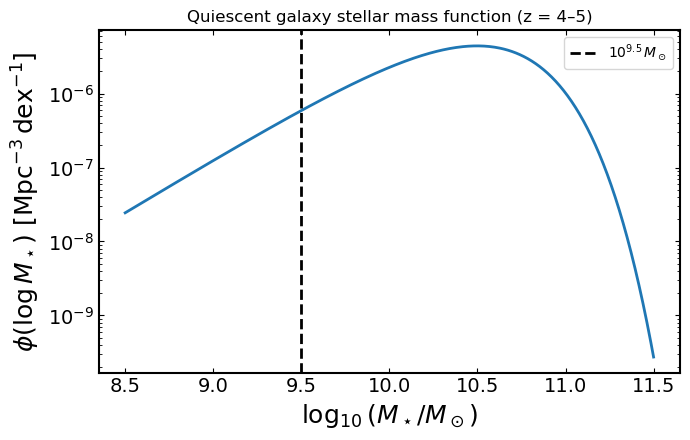

In [10]:
# ============================================================
# 5.3  Schechter SMF and predicted number density for
#      M* > 10^9.5 Msun in 4 < z < 5
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ------------------------------------------------------------
# Schechter parameters
# ------------------------------------------------------------
logM_star = 10.34
phi_star = 0.48e-5          # Mpc^-3
alpha = 0.44

logM_min = 9.5

# ------------------------------------------------------------
# Schechter function per dex in log10(M)
# ------------------------------------------------------------
def schechter_logM(logM, logM_star, phi_star, alpha):
    x = 10**(logM - logM_star)
    return np.log(10) * phi_star * (x**(alpha + 1.0)) * np.exp(-x)

# ------------------------------------------------------------
# Predicted number density above 10^9.5 Msun
# ------------------------------------------------------------
n_pred, n_err = quad(
    schechter_logM,
    logM_min, 13.0,
    args=(logM_star, phi_star, alpha)
)

print("=== Schechter prediction for M* > 10^9.5 Msun ===")
print(f"log(M*/Msun) = {logM_star}")
print(f"phi* = {phi_star:.3e} Mpc^-3")
print(f"alpha = {alpha:.2f}")
print(f"Predicted number density = {n_pred:.3e} Mpc^-3")
print(f"Observed number density  = {n_q:.3e} Mpc^-3")
print(f"Observed / predicted     = {n_q / n_pred:.2f}")

# ------------------------------------------------------------
# Plot the SMF
# ------------------------------------------------------------
logM_grid = np.linspace(8.5, 11.5, 400)
phi_logM = schechter_logM(logM_grid, logM_star, phi_star, alpha)

plt.figure(figsize=(7,4.5))
plt.plot(logM_grid, phi_logM, lw=2)
plt.axvline(logM_min, color="k", ls="--", label=r"$10^{9.5}\,M_\odot$")
plt.yscale("log")
plt.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
plt.ylabel(r"$\phi(\log M_\star)\ [{\rm Mpc}^{-3}\,{\rm dex}^{-1}]$")
plt.title("Quiescent galaxy stellar mass function (z = 4–5)")
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 — Number densities above 10^10𝑀⊙ and 10^10.5𝑀⊙

In [11]:
# ============================================================
# 5.4  Predicted number densities above 10^10 and 10^10.5 Msun
# ============================================================

from scipy.integrate import quad
import numpy as np

thresholds = [10.0, 10.5]

print("=== Predicted number densities from the Schechter SMF ===")
for logM_min in thresholds:
    n_pred, _ = quad(
        schechter_logM,
        logM_min, 13.0,
        args=(logM_star, phi_star, alpha)
    )
    print(f"M* > 10^{logM_min:.1f} Msun  ->  n = {n_pred:.3e} Mpc^-3")

=== Predicted number densities from the Schechter SMF ===
M* > 10^10.0 Msun  ->  n = 3.421e-06 Mpc^-3
M* > 10^10.5 Msun  ->  n = 1.649e-06 Mpc^-3


### 5.5 — Stellar mass density above 10^9.0𝑀⊙

In [12]:
# ============================================================
# 5.5  Stellar mass density of quiescent galaxies in 4 < z < 5
#      for M* > 10^9.0 Msun
# ============================================================

from scipy.integrate import quad
import numpy as np

logM_min = 9.0

# ------------------------------------------------------------
# Stellar mass density:
# rho_* = ∫ M * phi(logM) dlogM
# where phi(logM) is per dex
# ------------------------------------------------------------
def stellar_mass_density_integrand(logM, logM_star, phi_star, alpha):
    M = 10**logM
    return M * schechter_logM(logM, logM_star, phi_star, alpha)

rho_star, rho_err = quad(
    stellar_mass_density_integrand,
    logM_min, 13.0,
    args=(logM_star, phi_star, alpha)
)

print("=== Stellar mass density for M* > 10^9.0 Msun ===")
print(f"Lower integration limit = 10^{logM_min:.1f} Msun")
print(f"Stellar mass density = {rho_star:.3e} Msun Mpc^-3")

=== Stellar mass density for M* > 10^9.0 Msun ===
Lower integration limit = 10^9.0 Msun
Stellar mass density = 1.339e+05 Msun Mpc^-3


# 6 — Explore the photometry and spectra of 6620 and 8777


===== Galaxy 6620 =====
Photometry:
  wavelength range [Å]: 8982.433587036934 – 33587.60913299217
  flux range [nJy]: 21.790122985839844 – 1007.4183959960938
  median SNR: 9.999999450115954
Spectrum:
  wavelength range [Å]: 6031.652486825945 – 52941.360353656055
  flux range [µJy]: -0.04309861765946343 – 1.5805327401912617
  median SNR: 16.875685992239433


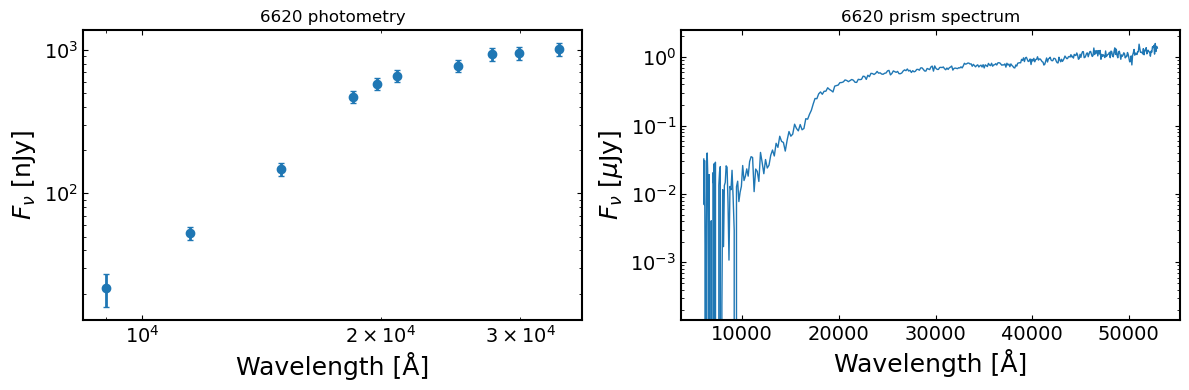


===== Galaxy 8777 =====
Photometry:
  wavelength range [Å]: 8982.433587036934 – 42801.766451581236
  flux range [nJy]: 241.34124755859375 – 2816.0927734375
  median SNR: 9.999999825045403
Spectrum:
  wavelength range [Å]: 6031.652486825945 – 52941.360353656055
  flux range [µJy]: -0.05280896444220136 – 3.8381664853378687
  median SNR: 34.85044621400417


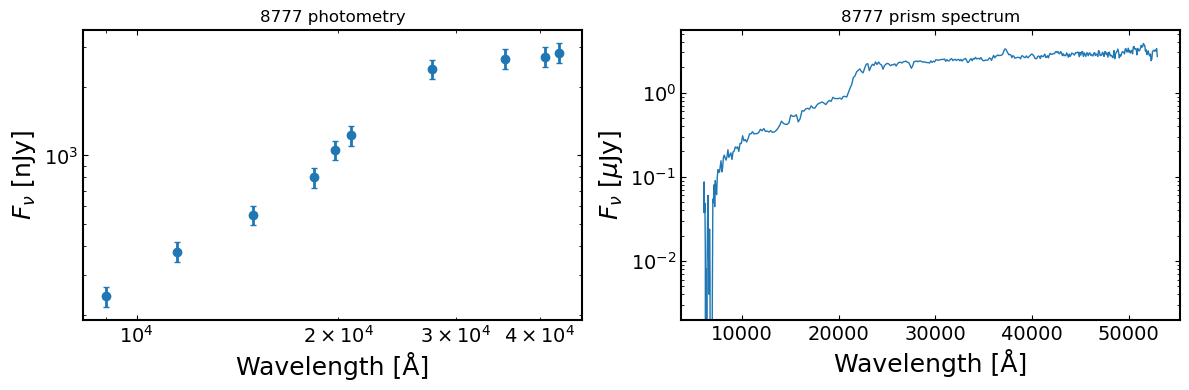

In [13]:
# ============================================================
# 6.1  Inspect photometry and spectra for 6620 and 8777
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import astropy.units as u

# ------------------------------------------------------------
# Photometry loader (same style as before)
# ------------------------------------------------------------
def load_photometry_raw(ID):
    data = Table.read(f"photometry/{ID}_photometry.fits", format="fits")
    wavelength = np.array(data["wavelength"][:10], dtype=float)   # Å
    flux_njy   = np.array(data["mags_obs"][:10], dtype=float)     # nJy
    err_njy    = np.array(data["mags_unc_obs"][:10], dtype=float) # nJy
    return wavelength, flux_njy, err_njy

# ------------------------------------------------------------
# Spectrum loader for quick plotting
# ------------------------------------------------------------
def load_spectrum_raw(ID):
    file_path = f"gds-barrufet-s67-v3_prism-clear_2198_{ID}.spec.fits"
    with fits.open(file_path) as hdul:
        data = hdul["SPEC1D"].data

        wave = np.array(data["wave"], dtype=float) * 1e4   # micron -> Å
        flux = np.array(data["flux"], dtype=float)         # µJy
        err  = np.array(data["err"], dtype=float)          # µJy

    m = np.isfinite(wave) & np.isfinite(flux) & np.isfinite(err)
    wave, flux, err = wave[m], flux[m], err[m]

    return wave, flux, err

# ------------------------------------------------------------
# Inspect both galaxies
# ------------------------------------------------------------
IDs = ["6620", "8777"]

for ID in IDs:
    print(f"\n===== Galaxy {ID} =====")

    # Photometry
    w_ph, f_ph, e_ph = load_photometry_raw(ID)
    print("Photometry:")
    print("  wavelength range [Å]:", w_ph.min(), "–", w_ph.max())
    print("  flux range [nJy]:", np.nanmin(f_ph), "–", np.nanmax(f_ph))
    print("  median SNR:", np.nanmedian(f_ph / e_ph))

    # Spectrum
    w_sp, f_sp, e_sp = load_spectrum_raw(ID)
    print("Spectrum:")
    print("  wavelength range [Å]:", w_sp.min(), "–", w_sp.max())
    print("  flux range [µJy]:", np.nanmin(f_sp), "–", np.nanmax(f_sp))
    print("  median SNR:", np.nanmedian(np.where(e_sp > 0, f_sp / e_sp, np.nan)))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].errorbar(w_ph, f_ph, yerr=e_ph, fmt="o", capsize=2)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Wavelength [Å]")
    axes[0].set_ylabel(r"$F_\nu$ [nJy]")
    axes[0].set_title(f"{ID} photometry")

    axes[1].plot(w_sp, f_sp, lw=1)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Wavelength [Å]")
    axes[1].set_ylabel(r"$F_\nu$ [$\mu$Jy]")
    axes[1].set_title(f"{ID} prism spectrum")

    plt.tight_layout()
    plt.show()

### Fast spectral fits for 6620 and 8777 with different SFHs

In [14]:
# ============================================================
# 6.2  Fast spectrum-only fits for 6620 and 8777
#      Compare delayed, dblplaw, and burst SFHs
# ============================================================

import bagpipes as pipes
import numpy as np
from astropy.io import fits

# ------------------------------------------------------------
# Reuse spectrum loader from before
# ------------------------------------------------------------
def load_nirspec_spectrum(ID, plotting=False):
    file_path = f"gds-barrufet-s67-v3_prism-clear_2198_{ID}.spec.fits"

    with fits.open(file_path) as hdul:
        data = hdul["SPEC1D"].data

        mask = np.isnan(data["flux"])
        data["flux"][mask] = 0.0
        data["err"][mask] = 1e30

        wavelength = 1e4 * data["wave"]   # micron -> Å
        flux = data["flux"]               # µJy
        flux_err = data["err"]            # µJy

        import astropy.units as u
        flux_cgs = (flux * u.uJy).to(
            u.erg / u.s / u.cm**2 / u.AA,
            equivalencies=u.spectral_density(wavelength * u.AA)
        ).value

        flux_cgs_err = (flux_err * u.uJy).to(
            u.erg / u.s / u.cm**2 / u.AA,
            equivalencies=u.spectral_density(wavelength * u.AA)
        ).value

    if plotting:
        return wavelength, flux, flux_err

    spectrum = np.c_[wavelength, flux_cgs, flux_cgs_err]
    mask = (spectrum[:, 0] > 7000.) & (spectrum[:, 0] < 51000.)
    return spectrum[mask]

# ------------------------------------------------------------
# Common settings
# ------------------------------------------------------------
with fits.open("jwst_nirspec_prism_disp.fits") as hdul:
    R_curve = np.c_[10000 * hdul[1].data["WAVELENGTH"], hdul[1].data["R"]]

dust = {"type": "Calzetti", "Av": (0., 4.)}
nebular = {"logU": (-4.5, -1.0)}

noise = {
    "type": "white_scaled",
    "scaling": (1., 10.),
    "scaling_prior": "log_10"
}

calib = {
    "type": "polynomial_bayesian",
    "0": (0.5, 1.5),
    "0_prior": "Gaussian",
    "0_prior_mu": 1.0,
    "0_prior_sigma": 0.25,
    "1": (-0.5, 0.5),
    "1_prior": "Gaussian",
    "1_prior_mu": 0.0,
    "1_prior_sigma": 0.25
}

sfh_models = {
    "delayed": {
        "delayed": {
            "tau": (0.1, 10.0),
            "age": (0.01, 2.5),
            "massformed": (6.0, 13.5),
            "metallicity": (0.0, 2.5)
        }
    },
    "dblplaw": {
        "dblplaw": {
            "tau": (0.0, 15.0),
            "alpha": (0.01, 1000.0),
            "beta": (0.01, 1000.0),
            "alpha_prior": "log_10",
            "beta_prior": "log_10",
            "massformed": (6.0, 15.0),
            "metallicity": (0.0, 2.5)
        }
    },
    "burst": {
        "burst": {
            "age": (0.01, 2.5),
            "massformed": (6.0, 15.0),
            "metallicity": (0.0, 2.5)
        }
    }
}

def pct(x):
    x = np.asarray(x, dtype=float)
    return np.percentile(x, [16, 50, 84])

# ------------------------------------------------------------
# Run fits
# ------------------------------------------------------------
IDs = ["6620", "8777"]
results_ext = {}

for ID in IDs:
    print(f"\n================ Galaxy {ID} ================")

    galaxy = pipes.galaxy(
        ID,
        load_nirspec_spectrum,
        spectrum_exists=True,
        photometry_exists=False
    )

    results_ext[ID] = {}

    for sfh_name, sfh_block in sfh_models.items():
        print(f"\n--- Running {ID} with {sfh_name} SFH ---")

        fit_instructions = {
            "redshift": (0.0, 10.0),
            "dust": dust,
            "nebular": nebular,
            "veldisp": (1.0, 1000.0),
            "veldisp_prior": "log_10",
            "R_curve": R_curve,
            "calib": calib,
            "noise": noise
        }
        fit_instructions.update(sfh_block)

        run_name = f"spec_only_{ID}_{sfh_name}_zfree_fast"

        fit_tmp = pipes.fit(galaxy, fit_instructions, run=run_name)
        fit_tmp.fit(verbose=True, sampler="nautilus", n_live=80, pool=4)

        samples = fit_tmp.posterior.samples
        row = {}

        for key in ["redshift", "stellar_mass", "sfr", "dust:Av"]:
            if key in samples:
                p16, p50, p84 = pct(samples[key])
                row[key] = (p16, p50, p84)

        results_ext[ID][sfh_name] = row

# ------------------------------------------------------------
# Print compact summary
# ------------------------------------------------------------
for ID in IDs:
    print(f"\n=== Summary for galaxy {ID} ===")
    print("Model       z                logM*             SFR              Av")
    for name, r in results_ext[ID].items():
        ztxt = f"{r['redshift'][1]:.2f} (+{r['redshift'][2]-r['redshift'][1]:.2f}/-{r['redshift'][1]-r['redshift'][0]:.2f})" if 'redshift' in r else "n/a"
        mtxt = f"{r['stellar_mass'][1]:.2f} (+{r['stellar_mass'][2]-r['stellar_mass'][1]:.2f}/-{r['stellar_mass'][1]-r['stellar_mass'][0]:.2f})" if 'stellar_mass' in r else "n/a"
        sfrtxt = f"{r['sfr'][1]:.2f} (+{r['sfr'][2]-r['sfr'][1]:.2f}/-{r['sfr'][1]-r['sfr'][0]:.2f})" if 'sfr' in r else "n/a"
        avtxt = f"{r['dust:Av'][1]:.2f} (+{r['dust:Av'][2]-r['dust:Av'][1]:.2f}/-{r['dust:Av'][1]-r['dust:Av'][0]:.2f})" if 'dust:Av' in r else "n/a"
        print(f"{name:10s} {ztxt:18s} {mtxt:18s} {sfrtxt:18s} {avtxt}")


================ Galaxy 6620 ================

--- Running 6620 with delayed SFH ---

Bagpipes: fitting object 6620

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Bagpipes: Latex turned off in rcParams, plots may look strange.0     | N/A      
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.


Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=113, pipe_handle=166)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<string>", line 1, in <module>
    from multiprocessing.spawn import spawn_main; spawn_main(tracker_fd=113, pipe_handle=170)
                                                  ~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/alberto/miniforge3/envs/galaxy_course/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/alberto/miniforge3/envs/galaxy_course/lib/python3.13/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/alberto/miniforge3/envs/galaxy_course/lib/python3.13/multiprocessing/spawn.py", line 132, in _main
    s

Bagpipes: Latex turned off in rcParams, plots may look strange.1     | -1064.80 
Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: Latex turned off in rcParams, plots may look strange.
Finished  | 58     | 1        | 4        | 18100    | N/A    | 2344  | -611.01  

Completed in 92.3 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
calib:0                        0.700      0.753      0.794
calib:1                        0.370      0.399      0.423
delayed:age                    1.517      1.640      1.788
delayed:massformed             9.922      9.959      9.991
delayed:metallicity            0.161      0.178      0.193
delayed:tau                    0.348      0.416      0.502
dust:Av                        3.410      3.470      3.531
nebular:logU                  -4.020     -3.759     -3.526
noise:scaling                  3.0

/Users/alberto/miniforge3/envs/galaxy_course/lib/python3.13/site-packages/bagpipes/models/star_formation_history.py:288: RuntimeWarning: overflow encountered in power
  sfr[mask] = ((t/tau)**alpha + (t/tau)**-beta)**-1


Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Bagpipes: Latex turned off in rcParams, plots may look strange.Bagpipes: Latex turned off in rcParams, plots may look strange.Bagpipes: Latex turned off in rcParams, plots may look strange.

Bagpipes: Latex turned off in rcParams, plots may look strange.

Finished  | 41     | 1        | 4        | 12900    | N/A    | 1343  | -495.91  

Completed in 55.1 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
burst:age                      0.769      0.817      0.967
burst:massformed              10.331     10.394     10.472
burst:metallicity              1.332      1.585      1.825
calib:0                        0.949      1.056      1.203
calib:1                        0.006      0.070     